# 📋 Análisis de Anotaciones — Archivos `.edf.st`

Los `.edf.st` son archivos PhysioBank que contienen:
- **Hipnograma**: etapas del sueño (W, S1–S4, REM, MT) por época de 30s
- **Eventos CAP fase A**: subtipo (A1, A2, A3), tiempo de inicio y duración

Este notebook los parsea, construye el hipnograma por paciente y resume los eventos CAP.

## 0 · Imports y configuración

In [7]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from pathlib import Path

mne.set_log_level('ERROR')
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

# ── AJUSTA ESTA RUTA ──────────────────────────────────────
BASE_PATH = Path.cwd() / '../data/cap-sleep-database'
# ─────────────────────────────────────────────────────────

OUT_DIR = BASE_PATH.parent / 'diagnostico_outputs'
OUT_DIR.mkdir(exist_ok=True)

st_files = sorted(BASE_PATH.glob('*.edf.st'))
print(f'Archivos .edf.st encontrados: {len(st_files)}')
for f in st_files[:5]:
    print(f'  {f.name}')
if len(st_files) > 5:
    print(f'  ... y {len(st_files)-5} más')

Archivos .edf.st encontrados: 108
  brux1.edf.st
  brux2.edf.st
  ins1.edf.st
  ins2.edf.st
  ins3.edf.st
  ... y 103 más


## 1 · Inspección de un archivo de ejemplo

Antes de procesar todos, inspeccionamos un archivo para entender la estructura.

In [9]:
import re

def parse_edf_st(filepath):
    """Extrae etapas de sueño del archivo .edf.st de CAP Sleep Database"""
    with open(filepath, 'rb') as f:
        content = f.read()
    
    # Decodificar ignorando errores
    text = content.decode('latin-1', errors='replace')
    
    # Buscar patrones de etapas: SLEEP-XX o WAKE
    # Formato observado: "SLEEP-S4 30 S4" o "CAP-A1 9 S4"
    stage_pattern = re.compile(r'(SLEEP-[^\x00\s]+|WAKE)\s+(\d+)', re.IGNORECASE)
    
    matches = stage_pattern.findall(text)
    
    records = []
    onset = 0.0
    for stage, duration in matches:
        dur = float(duration)
        records.append({
            'onset_s': onset,
            'duration_s': dur,
            'description': stage
        })
        onset += dur
    
    return pd.DataFrame(records)

# Probar con el primer archivo
ejemplo   = st_files[0]   # primer paciente; cambia el índice si quieres otro
ann_df = parse_edf_st(ejemplo)
print(f"Total épocas: {len(ann_df)}")
display(ann_df.head(20))
print('\nTipos únicos:')
print(ann_df['description'].value_counts().to_string())

Total épocas: 354


,onset_s,duration_s,description
0,0.0,30.0,SLEEP-S4
1,30.0,30.0,SLEEP-S4
2,60.0,30.0,SLEEP-S4
3,90.0,30.0,SLEEP-S4
4,120.0,30.0,SLEEP-S4
5,150.0,30.0,SLEEP-S4
6,180.0,30.0,SLEEP-S3
7,210.0,30.0,SLEEP-S0
8,240.0,30.0,SLEEP-S1
9,270.0,30.0,SLEEP-S0



Tipos únicos:
description
SLEEP-S2     173
SLEEP-REM     88
SLEEP-S0      38
SLEEP-S1      25
SLEEP-S4      20
SLEEP-S3      10


## 2 · Parser de anotaciones

Separamos cada anotación en:
- **Etapas del sueño** (`SLEEP-S0` a `SLEEP-S4`, `SLEEP-REM`, `SLEEP-MT`)
- **Eventos CAP fase A** (`CAP-A1`, `CAP-A2`, `CAP-A3`)
- **Otros eventos** (posición corporal, etc.)

In [15]:
# Mapeo de etiquetas de etapa → código numérico (convención R&K)
STAGE_MAP = {
    'SLEEP-S0':  0,   # Wake
    'SLEEP-S1':  1,
    'SLEEP-S2':  2,
    'SLEEP-S3':  3,
    'SLEEP-S4':  4,
    'SLEEP-REM': 5,
    'SLEEP-MT':  6,   # Movimiento corporal
}

STAGE_LABELS = {0: 'Wake', 1: 'S1', 2: 'S2', 3: 'S3', 4: 'S4', 5: 'REM', 6: 'MT'}
STAGE_COLORS = {
    0: '#E8E8E8',   # Wake — gris claro
    1: '#AED6F1',   # S1   — azul pálido
    2: '#2980B9',   # S2   — azul
    3: '#1A5276',   # S3   — azul oscuro
    4: '#0B2545',   # S4   — azul muy oscuro
    5: '#E74C3C',   # REM  — rojo
    6: '#F39C12',   # MT   — naranja
}

def parse_annotations(st_path):
    """
    Lee un .edf.st y devuelve dos DataFrames:
      - stages_df : hipnograma (onset, duration, stage_code, stage_label)
      - cap_df    : eventos CAP-A (onset, duration, subtype)
    """
    annots = mne.read_annotations(str(st_path))
    patient = st_path.name.replace('.edf.st', '')

    stages_rows = []
    cap_rows    = []

    for onset, duration, desc in zip(annots.onset, annots.duration, annots.description):
        desc_up = desc.strip().upper()

        # ── Etapa del sueño ─────────────────────────────────
        if desc_up in STAGE_MAP:
            stages_rows.append({
                'patient':     patient,
                'onset_s':     onset,
                'duration_s':  duration,
                'stage_code':  STAGE_MAP[desc_up],
                'stage_label': STAGE_LABELS[STAGE_MAP[desc_up]],
            })

        # ── Evento CAP fase A ────────────────────────────────
        elif 'CAP' in desc_up:
            # subtipo: A1, A2, A3 (o genérico A si no está especificado)
            if 'A1' in desc_up:   subtype = 'A1'
            elif 'A2' in desc_up: subtype = 'A2'
            elif 'A3' in desc_up: subtype = 'A3'
            else:                  subtype = 'A'

            cap_rows.append({
                'patient':    patient,
                'onset_s':    onset,
                'duration_s': duration,
                'subtype':    subtype,
                'raw_desc':   desc,
            })

    stages_df = pd.DataFrame(stages_rows)
    cap_df    = pd.DataFrame(cap_rows)
    return stages_df, cap_df


print('Parser definido ✅')

Parser definido ✅


## 3 · Procesar todos los pacientes

In [19]:
# Adaptar nombres de columnas al formato que espera el notebook
STAGE_CODE_MAP = {
    'W':  0, 'N1': 1, 'N2': 2, 'N3': 3, 'N4': 4, 'R': 5, 'MT': 6,
    # por si aparecen variantes
    'WAKE': 0, 'REM': 5,
}
STAGE_LABEL_MAP = {
    0: 'Wake', 1: 'S1', 2: 'S2', 3: 'S3', 4: 'S4', 5: 'REM', 6: 'MT'
}

stages_all['stage_code']  = stages_all['stage'].map(STAGE_CODE_MAP)
stages_all['stage_label'] = stages_all['stage_code'].map(STAGE_LABEL_MAP)
stages_all = stages_all.rename(columns={'subject': 'patient'})

# Verificar
sin_mapear = stages_all['stage_code'].isna().sum()
if sin_mapear > 0:
    print(f"⚠️  {sin_mapear} filas sin mapear. Valores únicos en 'stage':")
    print(stages_all[stages_all['stage_code'].isna()]['stage'].value_counts().to_string())
else:
    print("✅ Todas las etapas mapeadas correctamente")

stages_all['stage_code'] = stages_all['stage_code'].astype(int)
print(f"\n{stages_all.shape[0]:,} épocas | columnas: {stages_all.columns.tolist()}")
stages_all.head()

✅ Todas las etapas mapeadas correctamente

87,017 épocas | columnas: ['onset_s', 'duration_s', 'stage', 'stage_raw', 'patient', 'stage_code', 'stage_label']


,onset_s,duration_s,stage,stage_raw,patient,stage_code,stage_label
0,0.0,30.0,N3,SLEEP-S4,brux1,3,S3
1,30.0,30.0,N3,SLEEP-S4,brux1,3,S3
2,60.0,30.0,N3,SLEEP-S4,brux1,3,S3
3,90.0,30.0,N3,SLEEP-S4,brux1,3,S3
4,120.0,30.0,N3,SLEEP-S4,brux1,3,S3


In [16]:
import re

def parse_annotations(filepath):
    """
    Parser directo para archivos .edf.st de CAP Sleep Database.
    Lee el binario y extrae etapas y eventos CAP con regex.
    """
    with open(filepath, 'rb') as f:
        content = f.read()
    
    text = content.decode('latin-1', errors='replace')
    
    # --- Etapas de sueño ---
    # Patrones: SLEEP-S1, SLEEP-S2, SLEEP-S3, SLEEP-S4, SLEEP-REM, SLEEP-MT, WAKE
    stage_map = {
        'SLEEP-S1': 'N1', 'SLEEP-S2': 'N2',
        'SLEEP-S3': 'N3', 'SLEEP-S4': 'N3',
        'SLEEP-REM': 'REM', 'WAKE': 'Wake',
        'SLEEP-MT': 'MT'
    }
    
    stage_pattern = re.compile(
        r'(SLEEP-S[1-4]|SLEEP-REM|SLEEP-MT|WAKE)\s+(\d+)',
        re.IGNORECASE
    )
    
    stages = []
    onset = 0.0
    for match in stage_pattern.finditer(text):
        label_raw = match.group(1).upper()
        duration = float(match.group(2))
        stages.append({
            'onset_s':     onset,
            'duration_s':  duration,
            'stage':       stage_map.get(label_raw, label_raw),
            'stage_raw':   label_raw,
            'subject':     filepath.stem.replace('.edf', '')
        })
        onset += duration
    
    stages_df = pd.DataFrame(stages)
    
    # --- Eventos CAP (A1, A2, A3) ---
    cap_pattern = re.compile(
        r'(CAP-A[123])\s+(\d+(?:\.\d+)?)',
        re.IGNORECASE
    )
    
    cap_events = []
    for match in cap_pattern.finditer(text):
        cap_events.append({
            'onset_s':    float(match.start()),  # posición aproximada
            'cap_type':   match.group(1).upper(),
            'duration_s': float(match.group(2)),
            'subject':    filepath.stem.replace('.edf', '')
        })
    
    cap_df = pd.DataFrame(cap_events)
    
    return stages_df, cap_df

all_stages = []
all_cap    = []
total = len(st_files)

for i, st_path in enumerate(st_files, 1):
    print(f'  [{i:>3}/{total}] {st_path.stem}', end='\r')
    try:
        stages_df, cap_df = parse_annotations(st_path)
        all_stages.append(stages_df)
        all_cap.append(cap_df)
    except Exception as e:
        print(f'\n  ⚠️  Error en {st_path.name}: {e}')

stages_all = pd.concat(all_stages, ignore_index=True)
cap_all    = pd.concat(all_cap,    ignore_index=True)

print(f'\n✅ Procesados {total} archivos')
print(f'   Épocas de etapa   : {len(stages_all):,}')
print(f'   Eventos CAP-A     : {len(cap_all):,}')

  [108/108] sdb4.edfff
✅ Procesados 108 archivos
   Épocas de etapa   : 87,017
   Eventos CAP-A     : 49,956


## 4 · Distribución de etapas del sueño

,stage_label,horas_totales_dataset
0,S1,38.041667
1,S2,319.900000
2,S3,209.875000
3,REM,157.275000
4,MT,0.050000


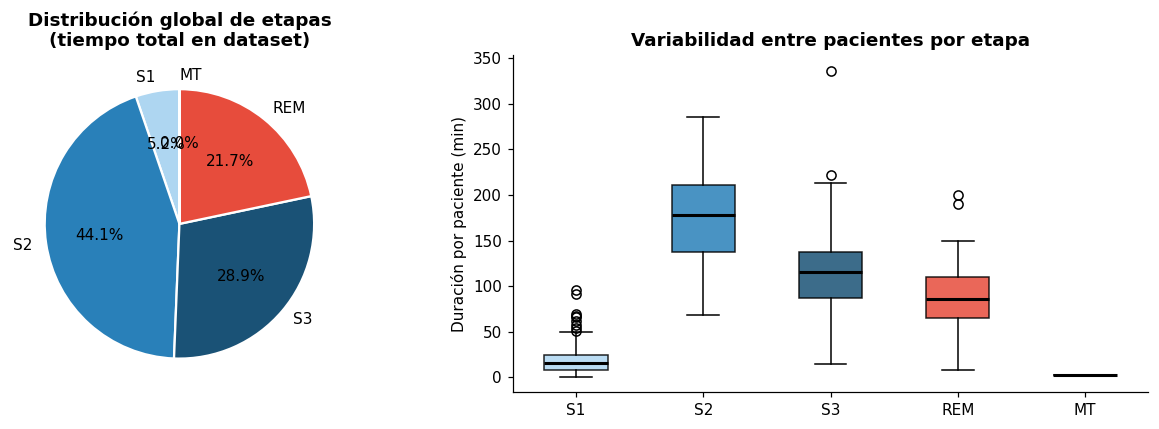

In [20]:
# Tiempo total por etapa (en horas)
stage_time = (
    stages_all
    .groupby(['stage_code', 'stage_label'])['duration_s']
    .sum()
    .reset_index()
    .assign(duration_h=lambda x: x['duration_s'] / 3600)
    .sort_values('stage_code')
)

# Tiempo por etapa por paciente
stage_per_patient = (
    stages_all
    .groupby(['patient', 'stage_code', 'stage_label'])['duration_s']
    .sum()
    .reset_index()
    .assign(duration_min=lambda x: x['duration_s'] / 60)
)

display(stage_time[['stage_label', 'duration_h']].rename(columns={'duration_h': 'horas_totales_dataset'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pastel de distribución global
colors = [STAGE_COLORS[c] for c in stage_time['stage_code']]
axes[0].pie(
    stage_time['duration_h'],
    labels=stage_time['stage_label'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Distribución global de etapas\n(tiempo total en dataset)', fontweight='bold')

# Boxplot por etapa (variabilidad entre pacientes)
order = sorted(stage_per_patient['stage_code'].unique())
labels_order = [STAGE_LABELS[c] for c in order]
box_colors   = [STAGE_COLORS[c] for c in order]

bp = axes[1].boxplot(
    [stage_per_patient[stage_per_patient['stage_code'] == c]['duration_min'].values for c in order],
    labels=labels_order,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2},
)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

axes[1].set_ylabel('Duración por paciente (min)')
axes[1].set_title('Variabilidad entre pacientes por etapa', fontweight='bold')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

,stage_label,horas_totales_dataset
0,S1,38.041667
1,S2,319.900000
2,S3,209.875000
3,REM,157.275000
4,MT,0.050000


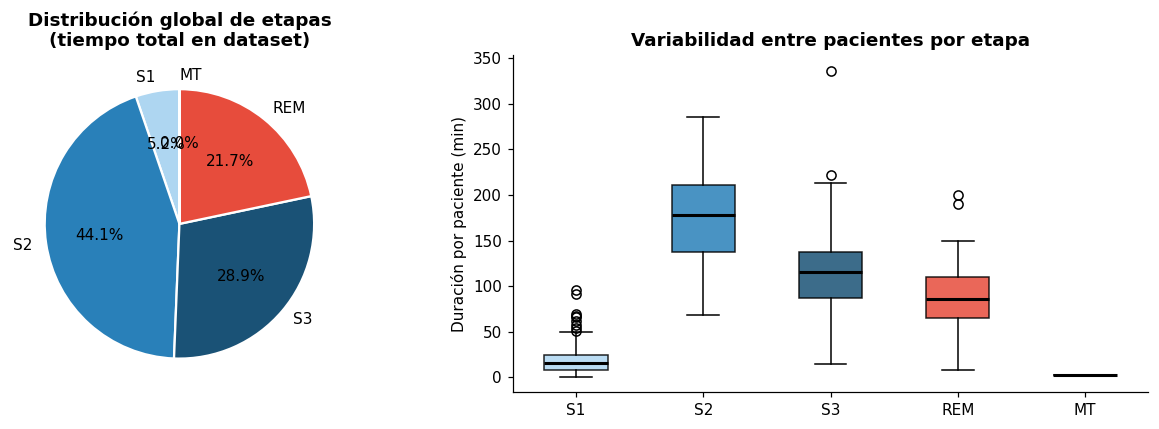

In [21]:
# Tiempo total por etapa (en horas)
stage_time = (
    stages_all
    .groupby(['stage_code', 'stage_label'])['duration_s']
    .sum()
    .reset_index()
    .assign(duration_h=lambda x: x['duration_s'] / 3600)
    .sort_values('stage_code')
)

# Tiempo por etapa por paciente
stage_per_patient = (
    stages_all
    .groupby(['patient', 'stage_code', 'stage_label'])['duration_s']
    .sum()
    .reset_index()
    .assign(duration_min=lambda x: x['duration_s'] / 60)
)

display(stage_time[['stage_label', 'duration_h']].rename(columns={'duration_h': 'horas_totales_dataset'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pastel de distribución global
colors = [STAGE_COLORS[c] for c in stage_time['stage_code']]
axes[0].pie(
    stage_time['duration_h'],
    labels=stage_time['stage_label'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Distribución global de etapas\n(tiempo total en dataset)', fontweight='bold')

# Boxplot por etapa (variabilidad entre pacientes)
order = sorted(stage_per_patient['stage_code'].unique())
labels_order = [STAGE_LABELS[c] for c in order]
box_colors   = [STAGE_COLORS[c] for c in order]

bp = axes[1].boxplot(
    [stage_per_patient[stage_per_patient['stage_code'] == c]['duration_min'].values for c in order],
    labels=labels_order,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2},
)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

axes[1].set_ylabel('Duración por paciente (min)')
axes[1].set_title('Variabilidad entre pacientes por etapa', fontweight='bold')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

## 5 · Hipnograma de un paciente

Visualiza la secuencia de etapas a lo largo de la noche para cualquier paciente.

✅ ['onset_s', 'subtype', 'duration_s', 'patient']


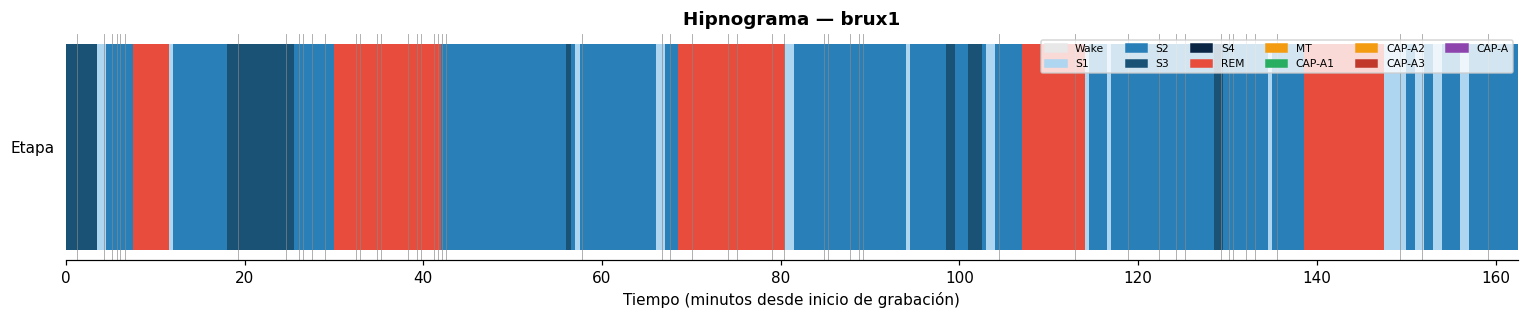

Eventos CAP-A en brux1: 60
subtype
CAP-A3    28
CAP-A1    26
CAP-A2     6


In [24]:
cap_all = cap_all.rename(columns={
    'subject':  'patient',
    'cap_type': 'subtype',
})
print("✅", cap_all.columns.tolist())

PACIENTE = stages_all['patient'].unique()[0]   # ← cambia por el paciente que quieras

df_p   = stages_all[stages_all['patient'] == PACIENTE].sort_values('onset_s')
cap_p  = cap_all[cap_all['patient'] == PACIENTE].sort_values('onset_s')

fig, ax = plt.subplots(figsize=(14, 3))

for _, row in df_p.iterrows():
    ax.barh(
        y=0, width=row['duration_s'], left=row['onset_s'] / 60,
        color=STAGE_COLORS[row['stage_code']], height=0.8, align='center'
    )

# Marcar eventos CAP-A
cap_colors = {'A1': '#27AE60', 'A2': '#F39C12', 'A3': '#C0392B', 'A': '#8E44AD'}
for _, row in cap_p.iterrows():
    ax.axvline(row['onset_s'] / 60, color=cap_colors.get(row['subtype'], '#888'),
               lw=0.6, alpha=0.7)

# Eje Y: etapas
ax.set_yticks([0])
ax.set_yticklabels(['Etapa'])

# Leyenda etapas
patches = [mpatches.Patch(color=STAGE_COLORS[c], label=STAGE_LABELS[c]) for c in sorted(STAGE_COLORS)]
# Leyenda CAP
cap_patches = [mpatches.Patch(color=v, label=f'CAP-{k}') for k, v in cap_colors.items()]
ax.legend(handles=patches + cap_patches, loc='upper right', fontsize=7, ncol=6)

ax.set_xlabel('Tiempo (minutos desde inicio de grabación)')
ax.set_title(f'Hipnograma — {PACIENTE}', fontweight='bold')
ax.set_xlim(0, df_p['onset_s'].max() / 60 + 5)
sns.despine(left=True)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

print(f'Eventos CAP-A en {PACIENTE}: {len(cap_p)}')
if not cap_p.empty:
    print(cap_p['subtype'].value_counts().to_string())

## 6 · Análisis de eventos CAP

In [25]:
# Resumen de CAP por paciente
cap_summary = (
    cap_all
    .groupby('patient')
    .agg(
        total_cap        = ('onset_s', 'count'),
        total_cap_dur_s  = ('duration_s', 'sum'),
        mean_cap_dur_s   = ('duration_s', 'mean'),
        n_A1             = ('subtype', lambda x: (x == 'A1').sum()),
        n_A2             = ('subtype', lambda x: (x == 'A2').sum()),
        n_A3             = ('subtype', lambda x: (x == 'A3').sum()),
    )
    .round(2)
    .reset_index()
    .sort_values('total_cap', ascending=False)
)

# Pacientes sin eventos CAP
patients_with_cap = cap_all['patient'].nunique()
total_patients    = stages_all['patient'].nunique()
print(f'Pacientes con eventos CAP : {patients_with_cap} / {total_patients}')
print(f'Total eventos CAP-A       : {len(cap_all):,}')
print(f'Duración media de CAP-A   : {cap_all["duration_s"].mean():.1f} s')
print()
display(cap_summary.head(15))

Pacientes con eventos CAP : 108 / 108
Total eventos CAP-A       : 49,956
Duración media de CAP-A   : 8.4 s



,patient,total_cap,total_cap_dur_s,mean_cap_dur_s,n_A1,n_A2,n_A3
45,nfle21,906,6463.0,7.13,0,0,0
69,nfle7,898,6814.0,7.59,0,0,0
36,nfle13,897,6087.0,6.79,0,0,0
107,sdb4,830,10347.0,12.47,0,0,0
66,nfle40,784,7435.0,9.48,0,0,0
86,rbd13,743,7629.0,10.27,0,0,0
75,plm3,742,5661.0,7.63,0,0,0
93,rbd2,711,6163.0,8.67,0,0,0
95,rbd21,688,5503.0,8.00,0,0,0
63,nfle38,674,6265.0,9.30,0,0,0


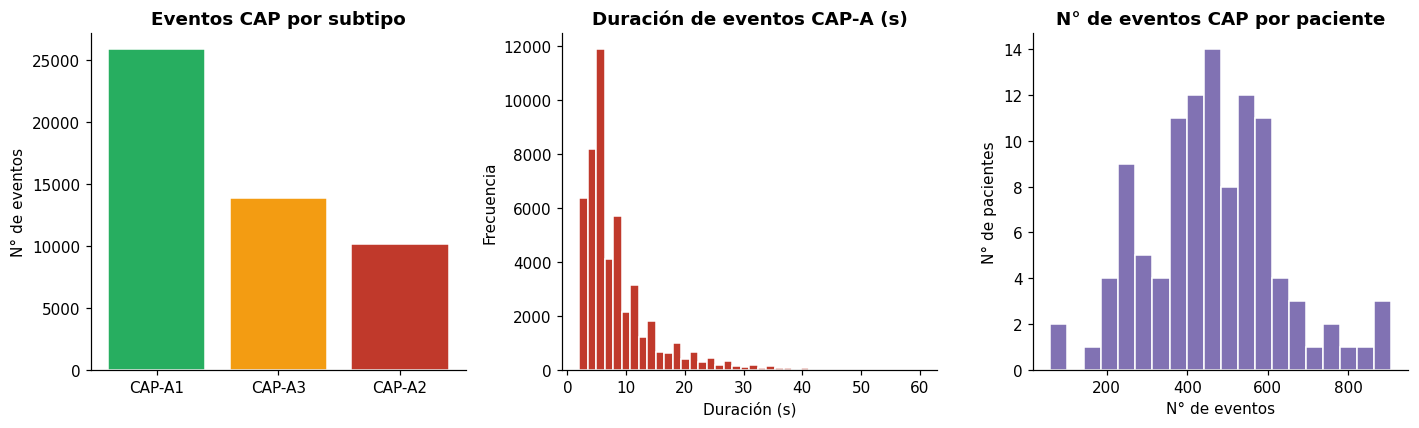

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Subtipo de CAP
subtype_counts = cap_all['subtype'].value_counts()
axes[0].bar(subtype_counts.index, subtype_counts.values,
            color=['#27AE60', '#F39C12', '#C0392B', '#8E44AD'],
            edgecolor='white')
axes[0].set_title('Eventos CAP por subtipo', fontweight='bold')
axes[0].set_ylabel('N° de eventos')
sns.despine(ax=axes[0])

# Distribución de duración de eventos CAP
axes[1].hist(cap_all['duration_s'].clip(upper=60), bins=40, color='#C0392B', edgecolor='white')
axes[1].set_title('Duración de eventos CAP-A (s)', fontweight='bold')
axes[1].set_xlabel('Duración (s)')
axes[1].set_ylabel('Frecuencia')
sns.despine(ax=axes[1])

# N° de CAP por paciente
axes[2].hist(cap_summary['total_cap'], bins=20, color='#8172B3', edgecolor='white')
axes[2].set_title('N° de eventos CAP por paciente', fontweight='bold')
axes[2].set_xlabel('N° de eventos')
axes[2].set_ylabel('N° de pacientes')
sns.despine(ax=axes[2])

plt.tight_layout()
plt.show()

## 7 · Balance de clases por trastorno

El prefijo del nombre del archivo indica el trastorno del paciente:

| Prefijo | Trastorno |
|---|---|
| `n` | Normal |
| `brux` | Bruxismo |
| `narco` | Narcolepsia |
| `nfle` | Epilepsia nocturna frontal |
| `plm` | Movimientos periódicos de extremidades |
| `rbd` | Trastorno de conducta en sueño REM |
| `sdb` | Trastorno respiratorio del sueño |
| `ins` | Insomnio |

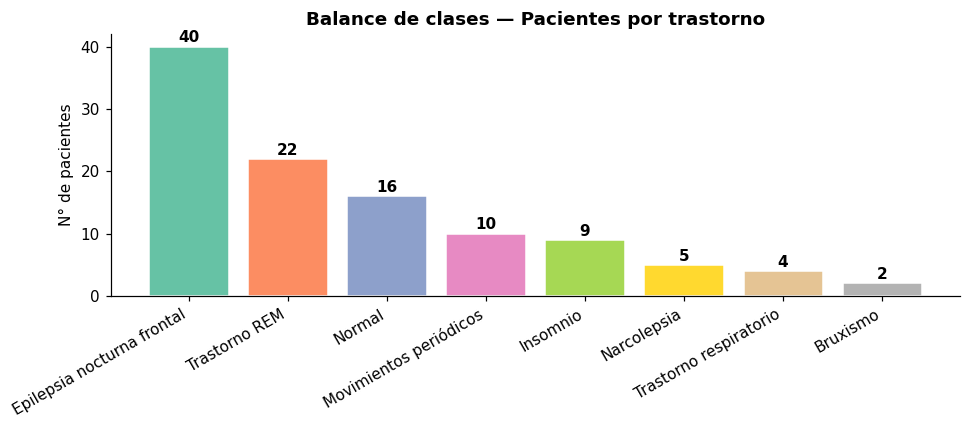

,disorder,n_pacientes
1,Epilepsia nocturna frontal,40
6,Trastorno REM,22
5,Normal,16
3,Movimientos periódicos,10
2,Insomnio,9
4,Narcolepsia,5
7,Trastorno respiratorio,4
0,Bruxismo,2


In [27]:
import re

DISORDER_MAP = {
    'brux':  'Bruxismo',
    'narco': 'Narcolepsia',
    'nfle':  'Epilepsia nocturna frontal',
    'plm':   'Movimientos periódicos',
    'rbd':   'Trastorno REM',
    'sdb':   'Trastorno respiratorio',
    'ins':   'Insomnio',
    'n':     'Normal',
}

def get_disorder(patient_name):
    name = patient_name.lower()
    for prefix in ['brux', 'narco', 'nfle', 'plm', 'rbd', 'sdb', 'ins']:
        if name.startswith(prefix):
            return DISORDER_MAP[prefix]
    if re.match(r'^n\d', name):    # n1, n2, n14... = normal
        return DISORDER_MAP['n']
    return 'Desconocido'

# Agregar etiqueta de trastorno a stages y cap
stages_all['disorder'] = stages_all['patient'].apply(get_disorder)
cap_all['disorder']    = cap_all['patient'].apply(get_disorder)

# Conteo de pacientes por trastorno
disorder_counts = (
    stages_all[['patient', 'disorder']]
    .drop_duplicates()
    .groupby('disorder')['patient']
    .count()
    .reset_index(name='n_pacientes')
    .sort_values('n_pacientes', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4))
palette = sns.color_palette('Set2', len(disorder_counts))
bars = ax.bar(disorder_counts['disorder'], disorder_counts['n_pacientes'],
              color=palette, edgecolor='white')

for bar, val in zip(bars, disorder_counts['n_pacientes']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(val), ha='center', va='bottom', fontweight='bold')

ax.set_title('Balance de clases — Pacientes por trastorno', fontsize=12, fontweight='bold')
ax.set_ylabel('N° de pacientes')
plt.xticks(rotation=30, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

display(disorder_counts)

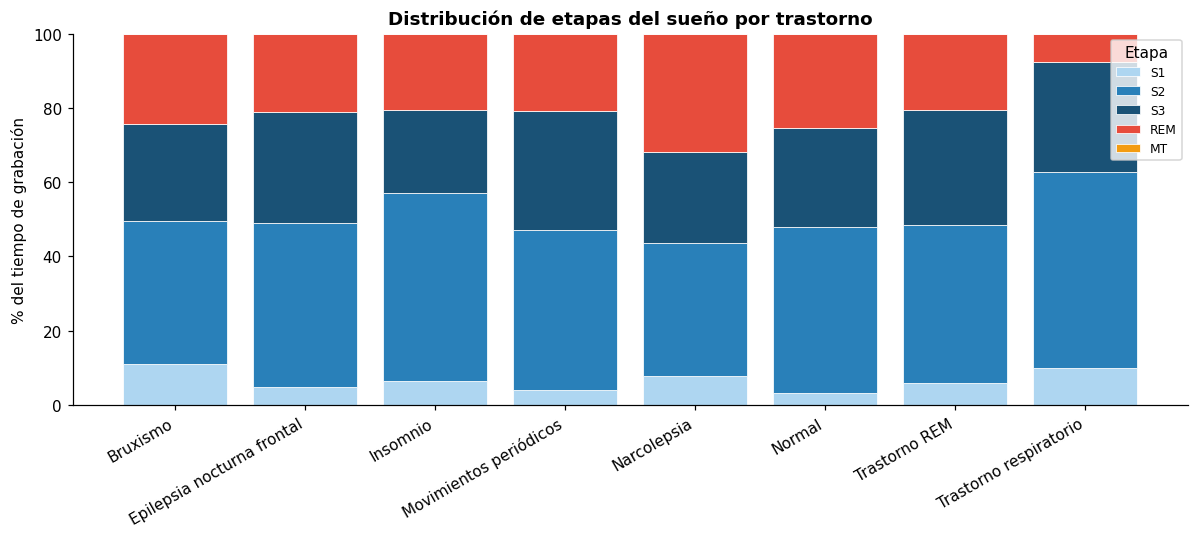

In [28]:
# Distribución de etapas por trastorno (% del tiempo)
stage_by_disorder = (
    stages_all
    .groupby(['disorder', 'stage_label'])['duration_s']
    .sum()
    .reset_index()
)
stage_by_disorder['pct'] = (
    stage_by_disorder.groupby('disorder')['duration_s']
    .transform(lambda x: x / x.sum() * 100)
)

pivot_stages = stage_by_disorder.pivot(index='disorder', columns='stage_label', values='pct').fillna(0)

fig, ax = plt.subplots(figsize=(11, 5))
stage_order  = ['Wake', 'S1', 'S2', 'S3', 'S4', 'REM', 'MT']
stage_order  = [s for s in stage_order if s in pivot_stages.columns]
bar_colors   = [STAGE_COLORS[{v: k for k, v in STAGE_LABELS.items()}[s]] for s in stage_order]

bottom = np.zeros(len(pivot_stages))
for stage, color in zip(stage_order, bar_colors):
    if stage in pivot_stages.columns:
        vals = pivot_stages[stage].values
        ax.bar(pivot_stages.index, vals, bottom=bottom, label=stage, color=color, edgecolor='white', linewidth=0.5)
        bottom += vals

ax.set_ylabel('% del tiempo de grabación')
ax.set_title('Distribución de etapas del sueño por trastorno', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, title='Etapa')
plt.xticks(rotation=30, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

## 8 · Exportar resultados

In [29]:
stages_all.to_csv(OUT_DIR / '07_hipnograma_completo.csv', index=False)
cap_all.to_csv(OUT_DIR / '08_eventos_cap.csv', index=False)
cap_summary.to_csv(OUT_DIR / '09_resumen_cap_por_paciente.csv', index=False)
disorder_counts.to_csv(OUT_DIR / '10_balance_clases.csv', index=False)

print(f'💾 CSVs guardados en: {OUT_DIR.resolve()}')
print()
print('  07_hipnograma_completo.csv       — etapas de sueño de todos los pacientes')
print('  08_eventos_cap.csv               — todos los eventos CAP-A con subtipo')
print('  09_resumen_cap_por_paciente.csv  — conteo y duración de CAP por paciente')
print('  10_balance_clases.csv            — n° de pacientes por trastorno')

💾 CSVs guardados en: C:\Users\LilyG\Documents\Fusión de Datos\RAHBFDP-2026\data\diagnostico_outputs

  07_hipnograma_completo.csv       — etapas de sueño de todos los pacientes
  08_eventos_cap.csv               — todos los eventos CAP-A con subtipo
  09_resumen_cap_por_paciente.csv  — conteo y duración de CAP por paciente
  10_balance_clases.csv            — n° de pacientes por trastorno
